In [ ]:
# --- Repository root ---------------------------------------------------------
# Every path in this notebook is relative to the repository root, not to notebooks/.
# Resolve the root and work from there, so the notebook behaves the same whether it
# was opened from notebooks/ or from the repository root.
import os
from pathlib import Path

for _d in (Path.cwd(), *Path.cwd().parents):
    if (_d / "processing_scripts").is_dir() and (_d / "README.md").is_file():
        os.chdir(_d)
        break
else:
    raise RuntimeError("repository root not found — open this notebook inside a clone "
                       "of the H3K27me2 repository")
print("working directory:", Path.cwd())

In [1]:
import os
import numpy as np
import pandas as pd
#import scanpy as sc
import pyranges as pr
import warnings
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
from scipy import stats
from tabulate import tabulate
from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [4]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [5]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [6]:
fig_dir = 'figures/'

# bulk data

In [7]:
df_path = 'data/2024/RepliTag/Matrices/coverage_scores_bulk_10kb.tab'
bins = pd.read_csv(df_path, sep='\t', header = 0)
bins.fillna(0,inplace = True)

#simplify col_names
def simplify_column(col):
    if "JG_HsDm_K562" in col:
        parts = col.split("_")
        return f"{parts[3]}_{parts[5]}"
    return col

# Apply to all columns
bins.columns = bins.columns.str.replace(r"[\'#]", "", regex=True)
bins.columns = [simplify_column(col) for col in bins.columns]
bins.columns
bins['ID'] = bins['chr'].astype('str') + '_' + bins['start'].astype('str') + '_' +bins['end'].astype('str')
# Define standard chromosomes
standard_chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

# Filter bins to keep only rows with standard chromosomes
bins = bins[bins['chr'].isin(standard_chromosomes)]
bins

,chr,start,end,K27ac_K_no_chrM.1-1000,K27me1_K_no_chrM.1-1000,K27me2_K_no_chrM.1-1000,K27me3_K_no_chrM.1-1000,P2_K_no_chrM.1-1000,wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig,ID
0,chr11,0,10000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,chr11_0_10000
1,chr11,10000,20000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,chr11_10000_20000
2,chr11,20000,30000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,chr11_20000_30000
3,chr11,30000,40000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,chr11_30000_40000
4,chr11,40000,50000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,chr11_40000_50000
...,...,...,...,...,...,...,...,...,...,...
309166,chr13,114320000,114330000,2.872727,1.534794,0.337325,0.204999,1.984826,60.458517,chr13_114320000_114330000
309167,chr13,114330000,114340000,1.130504,1.269310,0.927371,0.294010,1.003902,58.950978,chr13_114330000_114340000
309168,chr13,114340000,114350000,1.151106,0.956924,1.009839,0.843907,1.297140,57.970843,chr13_114340000_114350000
309169,chr13,114350000,114360000,2.287503,4.214759,0.631890,0.728138,2.957881,0.000000,chr13_114350000_114360000


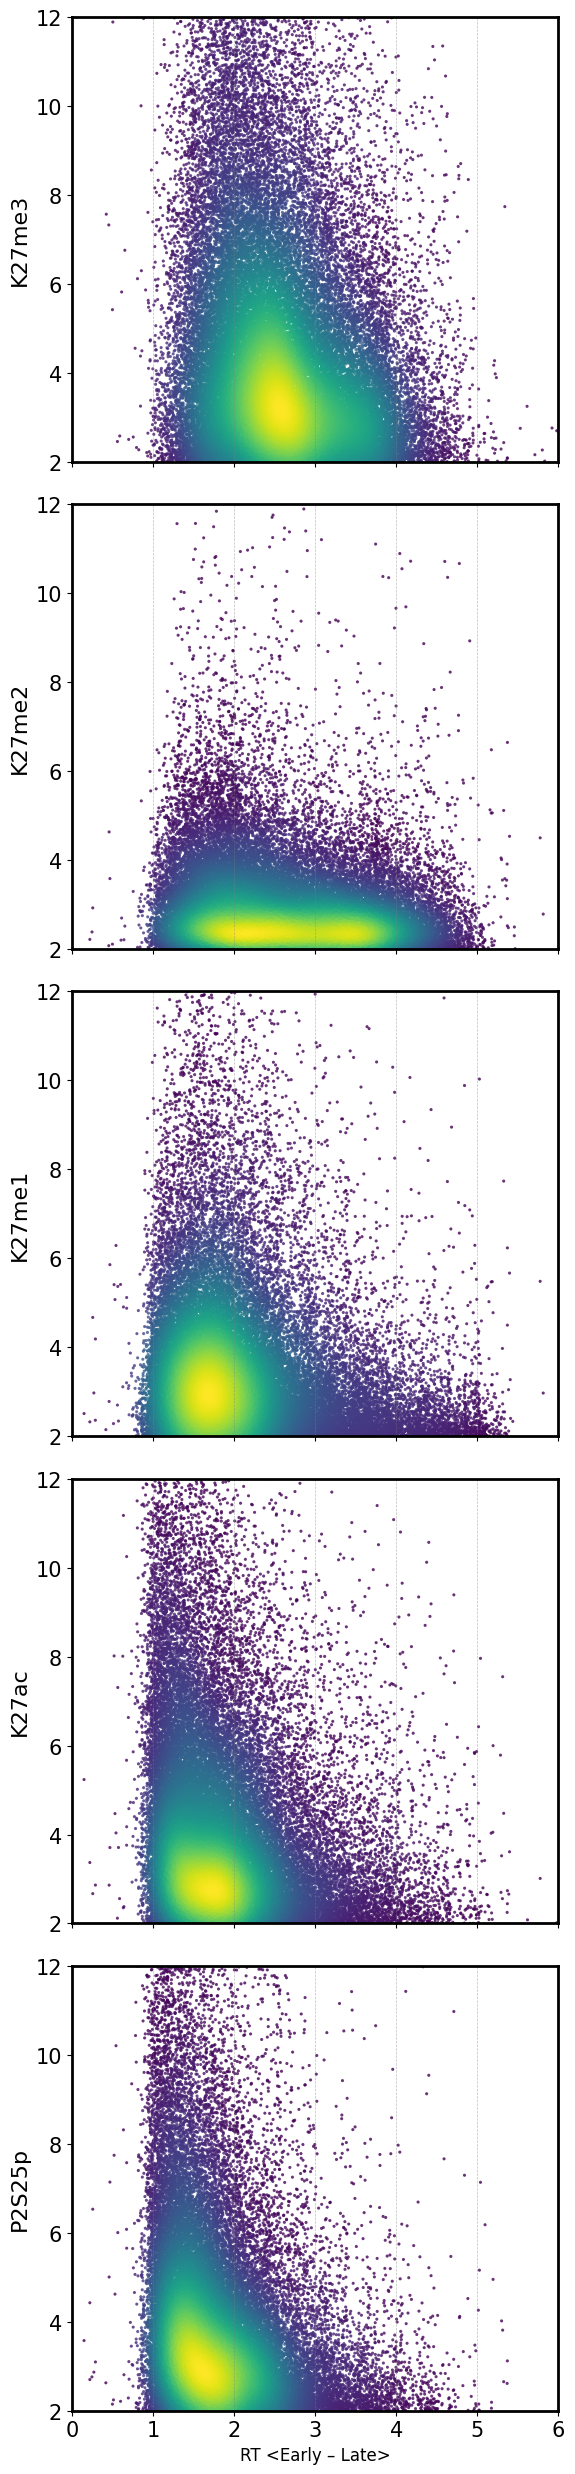

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Define marks and columns
mark_columns = {
    "K27me3": ['K27me3_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me2": ['K27me2_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me1": ['K27me1_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27ac":  ['K27ac_K_no_chrM.1-1000',  'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "P2S25p": ['P2_K_no_chrM.1-1000',    'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
}

colors = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

fig, axes = plt.subplots(
    nrows=len(mark_columns),
    ncols=1,
    figsize=(6, 25),
    sharex=True
)

for ax, (mark, columns), color in zip(axes, mark_columns.items(), colors):
    # filter raw data
    df_mark = bins[columns].copy()
    df_mark = df_mark[df_mark[columns[1]] > 0]

    # compute RT (x) and signal (y)
    x_all = (1 - (df_mark[columns[1]] / 100)) * 6
    y_all = df_mark[columns[0]]

    # fixed cutoff at 4
    cutoff = 2
    mask = y_all >= cutoff
    x_filt = x_all[mask].reset_index(drop=True)
    y_filt = y_all[mask].reset_index(drop=True)

    # downsample & compute 2D density
    downsample_size = 1000
    n_pts = len(x_filt)
    idx = np.random.choice(n_pts, size=min(downsample_size, n_pts), replace=False)
    x_samp = x_filt.iloc[idx]
    y_samp = y_filt.iloc[idx]
    xy_samp = np.vstack([x_samp, y_samp])
    kde = gaussian_kde(xy_samp)
    xy_all = np.vstack([x_filt, y_filt])
    density = kde(xy_all)
    density_norm = (density - density.min()) / (density.max() - density.min())

    # scatter with density coloring
    ax.scatter(
        x_filt,
        y_filt,
        c=density_norm,
        cmap='viridis',
        s=5,
        edgecolors='none',
        rasterized = True,
        alpha=0.8
    )

    # formatting
    ax.set_xlim(0, 6)
    ax.set_ylim(cutoff, 12)
    ax.set_ylabel(mark, fontsize=16)
    ax.set_title('')
    ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# common x‐axis label
axes[-1].set_xlabel("RT <Early – Late>", fontsize=12)

plt.tight_layout()
plt.savefig(
    fig_dir + '250508_min2_bulkRT_density_scat.pdf',
    transparent=True,
    bbox_inches='tight',dpi=300
    #facecolor = 'black'
)
plt.show()


In [315]:
# Corrected code for preparing data for KS test
df = bins[['K27me3_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig']]
df = df[(df.iloc[:, 1] > 0) & (df.iloc[:, 1] <= 100) & (df.iloc[:, 0] > 2)]
me3 = (1 - (df.iloc[:, 1] / 100)) * 6  # Corrected to use RT values

df = bins[['K27me2_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig']]
df = df[(df.iloc[:, 1] > 0) & (df.iloc[:, 1] <= 100) & (df.iloc[:, 0] > 2)]
me2 = (1 - (df.iloc[:, 1] / 100)) * 6  # Corrected to use RT values

df = bins[['K27me1_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig']]
df = df[(df.iloc[:, 1] > 0) & (df.iloc[:, 1] <= 100) & (df.iloc[:, 0] > 2)]
me1 = (1 - (df.iloc[:, 1] / 100)) * 6  # Corrected to use RT values

df = bins[['K27ac_K_no_chrM.1-1000', 'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig']]
df = df[(df.iloc[:, 1] > 0) & (df.iloc[:, 1] <= 100) & (df.iloc[:, 0] > 2)]
ac = (1 - (df.iloc[:, 1] / 100)) * 6  # Corrected to use RT values

print(f"K27me3 (n={len(me3)})")
print(f"K27me2 (n={len(me2)})")
print(f"K27me1 (n={len(me1)})")
print(f"K27ac (n={len(ac)})")


K27me3 (n=51216)
K27me2 (n=46712)
K27me1 (n=45110)
K27ac (n=48443)


In [318]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests

# your column definitions
mark_columns = {
    "K27me3": ['K27me3_K_no_chrM.1-1000',
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me2": ['K27me2_K_no_chrM.1-1000',
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me1": ['K27me1_K_no_chrM.1-1000',
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27ac" : ['K27ac_K_no_chrM.1-1000',
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "P2S25p": ['P2_K_no_chrM.1-1000',
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
}

def downsample_rt(df, cols, sample_size=1000, seed=42):
    """
    Returns a NumPy array of RT values, downsampled to sample_size if needed.
    cols = [signal_col, RT_col]
    """
    np.random.seed(seed)
    sub = df[cols].dropna()
    sub = sub[(sub.iloc[:,1]>0) & (sub.iloc[:,1]<=100) & (sub.iloc[:,0]>2)]
    rt = (1 - sub.iloc[:,1]/100) * 6
    if len(rt) > sample_size:
        return rt.sample(sample_size, random_state=seed).to_numpy()
    else:
        return rt.to_numpy()

# define exactly the four comparisons you want
pairs = [
    ("K27me3","K27me2"),
    ("K27me2","K27me1"),
    ("K27me1","K27ac"),
    ("K27ac", "P2S25p")
]

pvals = []
results = []

for m1, m2 in pairs:
    r1 = downsample_rt(bins, mark_columns[m1], sample_size=500, seed=42)
    r2 = downsample_rt(bins, mark_columns[m2], sample_size=500, seed=42)
    stat, p = ks_2samp(r1, r2)
    pvals.append(p)
    results.append({"comparison":f"{m1} vs {m2}", "p_uncorrected":p})

# BH correction
p_corr = multipletests(pvals, method='fdr_bh')[1]
for i, res in enumerate(results):
    res["p_BH"] = p_corr[i]

# turn into a DataFrame and print
df_out = pd.DataFrame(results)
print(df_out.to_string(index=False))


      comparison  p_uncorrected         p_BH
K27me3 vs K27me2   2.899596e-02 5.799192e-02
K27me2 vs K27me1   1.257741e-26 5.030963e-26
 K27me1 vs K27ac   1.497319e-01 1.980421e-01
 K27ac vs P2S25p   1.980421e-01 1.980421e-01


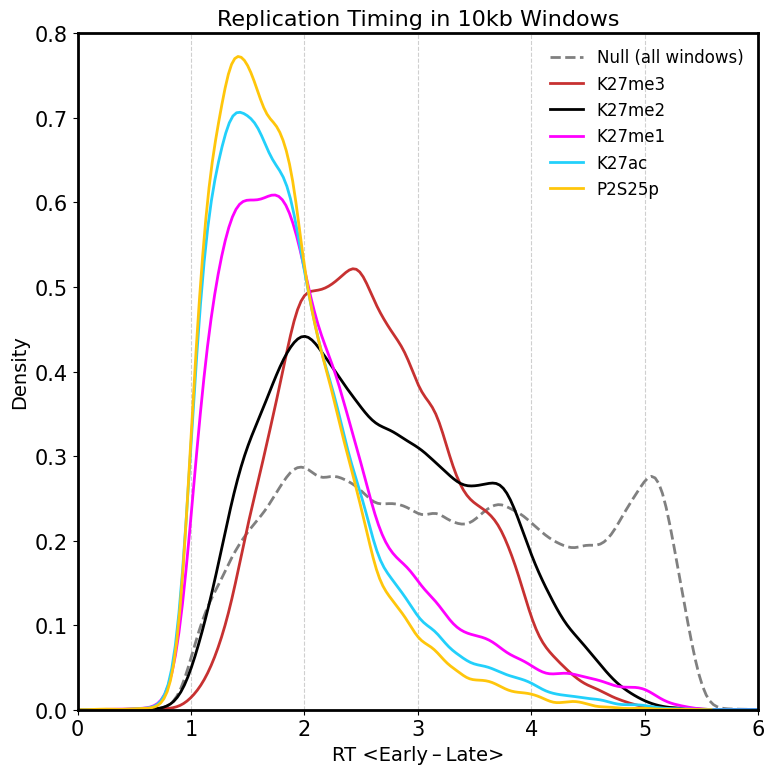

In [323]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define marks and columns
mark_columns = {
    "K27me3": ['K27me3_K_no_chrM.1-1000', 
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me2": ['K27me2_K_no_chrM.1-1000', 
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27me1": ['K27me1_K_no_chrM.1-1000', 
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "K27ac":  ['K27ac_K_no_chrM.1-1000',  
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
    "P2S25p": ['P2_K_no_chrM.1-1000',    
               'wgEncodeUwRepliSeqK562WaveSignalRep1_hg38.bigWig'],
}
colors = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Build null RT distribution
all_rt = []
for cols in mark_columns.values():
    df0 = bins[cols].dropna()
    df0 = df0[(df0[cols[1]] > 0) & (df0[cols[1]] <= 100)]
    rt = (1 - df0[cols[1]] / 100) * 6
    all_rt.extend(rt)
all_rt = np.array(all_rt)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))      # square figure
sns.kdeplot(all_rt, ax=ax,
            color='gray', linestyle='--',
            label='Null (all windows)', linewidth=2)

for (mark, cols), col in zip(mark_columns.items(), colors):
    dfm = bins[cols].dropna()
    dfm = dfm[(dfm[cols[1]] > 0) & (dfm[cols[1]] <= 100) & (dfm[cols[0]] > 2)]
    x = (1 - dfm[cols[1]] / 100) * 6
    sns.kdeplot(x, ax=ax,
                color=col,
                label=mark,
                linewidth=2)

ax.set_xlabel("RT <Early – Late>", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.set_xlim(0, 6)
ax.set_ylim(0, 0.8)
ax.set_title("Replication Timing in 10kb Windows", fontsize=16)
ax.legend(frameon=False, fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(
    fig_dir + '250508_min2_bulkRT_kde.pdf',
    transparent=True,
    bbox_inches='tight',dpi=300
    #facecolor = 'black'
)
plt.show()
